# Artificial Neural Network — Regression

In this notebook, we will build an Artificial Neural Network (ANN)
using TensorFlow 2.0 to predict the net hourly electrical energy
output (PE) of a Combined Cycle Power Plant, based on ambient
environmental conditions.

We will use the `Folds5x2_pp.xlsx` dataset, which contains 9,568
data points collected from a real power plant over 6 years
(2006-2011), while the plant was operating at full load.

Unlike the churn prediction notebook (a classification problem
with a binary output), this is a **regression problem**: the goal
is to predict a continuous numerical value (the power output in
MW), not a class label.

## Workflow
1. Import the required libraries.
2. Explore the dataset.
3. Preprocess the dataset (including Feature Scaling).
4. Build the ANN model.
5. Train the model.
6. Evaluate the model using regression metrics.
7. Visualize the results.

### Importing the libraries

We import the core libraries needed throughout the notebook:

- **NumPy** for numerical operations and array manipulation.
- **Pandas** for loading and handling the dataset.
- **TensorFlow** for building and training the neural network.
- **Matplotlib** and **Seaborn** for exploring the data and
  visualizing the model's performance.

In [24]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
tf.__version__

'2.20.0'

## Part 1 - Data Preprocessing

We start by loading the dataset and exploring the relationships
between the features and the target variable. Since all the
features here are already numerical (there are no categorical
columns like "Gender" or "Geography" in this dataset), we skip
the encoding steps that were needed in the classification project.

### Importing the dataset

The dataset (`Folds5x2_pp.xlsx`) contains 4 environmental features
and 1 target variable:

| Column | Description |
|---|---|
| AT | Ambient Temperature (°C) |
| V  | Exhaust Vacuum (cm Hg) |
| AP | Ambient Pressure (millibar) |
| RH | Relative Humidity (%) |
| PE | Net hourly electrical energy output (MW) — **Target** |

We load the file into a Pandas DataFrame, then separate the
features (`X`) — all columns except the last one — from the
target variable (`y`), which is the last column, "PE".

In [26]:
dataset = pd.read_excel('Folds5x2_pp.xlsx')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [27]:
print(X)

[[  14.96   41.76 1024.07   73.17]
 [  25.18   62.96 1020.04   59.08]
 [   5.11   39.4  1012.16   92.14]
 ...
 [  31.32   74.33 1012.92   36.48]
 [  24.48   69.45 1013.86   62.39]
 [  21.6    62.52 1017.23   67.87]]


In [28]:
print(y)

[463.26 444.37 488.56 ... 429.57 435.74 453.28]


### Exploring Feature Correlations

Before building the model, it's useful to explore how strongly
each feature is related to the target variable (`PE`), and to
each other, using a correlation heatmap.

- Values close to **+1** mean a strong positive correlation.
- Values close to **-1** mean a strong negative correlation.
- Values close to **0** mean little to no linear relationship.

This helps us understand which environmental factors have the
biggest influence on the power plant's energy output before we
even train the model.

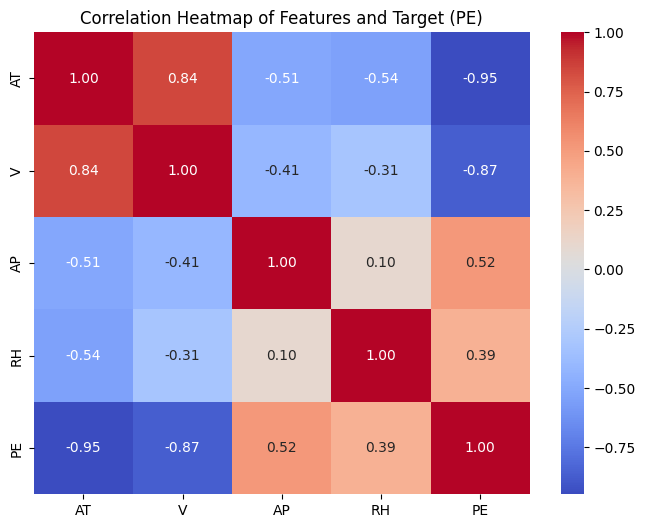

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(dataset.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Features and Target (PE)')
plt.show()

### Splitting the dataset into the Training set and Test set

We split the data into a training set (80%) and a test set (20%).
The model will learn from the training set, and we'll evaluate
its performance afterward on the unseen test set.

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Feature Scaling

Although Feature Scaling isn't strictly required for ANN
regression when the features are already on relatively similar
numerical scales, applying it is still a good practice: it helps
the model converge faster and more reliably during training, and
ensures no single feature dominates the learning process just
because it has larger raw values (e.g., `AP`, in the thousands,
vs. `AT`, in the tens).

We apply `StandardScaler` to standardize the features so they
have a mean of 0 and a standard deviation of 1. As always, we fit
the scaler only on the training set, then use it to transform
both the training and test sets, to avoid data leakage.

> **Note:** We only scale the features (`X`), **not** the target
> variable (`y`). This way, the model's predictions come out
> directly in the original unit (MW), with no need to reverse the
> scaling afterward.

In [31]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Part 2 - Building the ANN

We now build the architecture of our Artificial Neural Network
using Keras' Sequential API — an input layer, two hidden layers,
and an output layer. The architecture is nearly identical to the
classification model, with one key difference: the output layer.

### Initializing the ANN

We initialize the ANN as a sequence of layers using the
`Sequential` class from Keras.

In [32]:
ann = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

We add the first fully-connected (Dense) hidden layer with 6
neurons and the ReLU activation function.

In [33]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

### Adding the second hidden layer

We add a second hidden layer, also with 6 neurons and ReLU
activation, to increase the model's ability to learn complex
non-linear relationships in the data.

In [34]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

### Adding the output layer

Since this is a **regression** problem (predicting a continuous
value, not a class), the output layer has a single neuron with
**no activation function** (i.e., a linear activation). This
allows the model to output any real number, which is necessary
since the power output (PE) is a continuous value roughly between
420 and 496 MW — not a probability between 0 and 1 like in the
classification project.

In [35]:
ann.add(tf.keras.layers.Dense(units=1))

## Part 3 - Training the ANN

With the architecture defined, we now compile the model and train
it on our training data.

### Compiling the ANN

We compile the ANN by specifying:
- **Optimizer:** `adam`, an efficient stochastic gradient descent
  algorithm.
- **Loss function:** `mean_squared_error` (MSE), the standard loss
  function for regression problems. It measures the average
  squared difference between the predicted and actual values —
  unlike `binary_crossentropy`, which was used for the
  classification problem.

Note that we don't specify an `accuracy` metric here, since
accuracy is a classification concept and doesn't apply to
regression problems.

In [36]:
ann.compile(optimizer='adam', loss='mean_squared_error')

### Training the ANN model on the Training set

We train the model on the training set for 100 epochs with a
batch size of 32. We also set `validation_split = 0.2` to monitor
the model's performance on unseen data during training, and we
save the result in the `history` variable to visualize the
training progress afterward.

In [37]:
history = ann.fit(X_train, y_train, batch_size=32, epochs=100, validation_split=0.2)

Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 206375.4219 - val_loss: 205356.4375
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 204002.5938 - val_loss: 201162.9375
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 194430.1875 - val_loss: 183968.6406
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 169322.1094 - val_loss: 150261.9531
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 130443.6641 - val_loss: 108423.5938
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 90847.8906 - val_loss: 73492.8984
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 61222.4219 - val_loss: 49765.6523
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 41231.6172 - val_loss: 33639.0781
Epoch 9/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 28051.0527 - val_loss: 23294.9609
Epoch 10/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20087.8848 - val_loss: 17135.4316
Epoch 11/100
192/192 ━━━━━━━━━━━━━━━━━━

## Part 4 - Making the predictions and evaluating the model

Now that our ANN is trained, we use it to predict the power
output on the test set and evaluate how accurate those
predictions are using regression-specific metrics.

### Predicting the Test set results

We use the trained model to predict the power output (PE) for
every observation in the test set, and compare the predicted
values side-by-side with the actual values.

> Note: Since we scaled `X_test` with the same `sc` scaler fitted
> on the training set, the model receives properly scaled input.
> No inverse transformation is needed on the output, since `y`
> was never scaled in the first place.

In [38]:
y_pred = ann.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[432.33 431.23]
 [459.68 460.01]
 [464.1  461.14]
 ...
 [471.07 473.26]
 [442.27 438.  ]
 [462.54 463.28]]


### Evaluating the Model's Performance

Since this is a regression problem, we can't use accuracy or a
confusion matrix. Instead, we evaluate the model using metrics
designed for continuous predictions:

- **R² Score (Coefficient of Determination):** Measures how much
  of the variance in the target variable is explained by the
  model. Ranges from 0 to 1 (closer to 1 is better); a value of
  0.9, for example, means the model explains 90% of the
  variability in the power output.
- **MAE (Mean Absolute Error):** The average absolute difference
  between predicted and actual values, in the same units as the
  target (MW). Easy to interpret directly.
- **RMSE (Root Mean Squared Error):** Similar to MAE, but
  penalizes larger errors more heavily, since it's based on
  squared differences.

In [39]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f} MW')
print(f'RMSE: {rmse:.4f} MW')

R² Score: 0.9329
MAE: 3.5426 MW
RMSE: 4.4302 MW


## Part 5 - Visualizing the Model's Performance

Finally, we visualize the training process and the quality of the
model's predictions, to get a clearer, more intuitive picture of
how well the ANN is performing.

### Plotting the Training and Validation Loss

This plot shows how the Mean Squared Error (loss) evolved over
the 100 training epochs, for both the training and validation
sets.

Since the loss value starts very high and drops sharply within
the first few epochs, we plot the y-axis on a **logarithmic
scale**. This makes it possible to clearly see the improvement
across *all* epochs — including the later, more gradual ones —
instead of the curve looking like a flat line after a single
sharp drop.

- If both curves decrease and stay close together, the model is
  learning well and generalizing properly.
- If the training loss keeps decreasing while the validation loss
  increases or plateaus, this indicates **overfitting**.

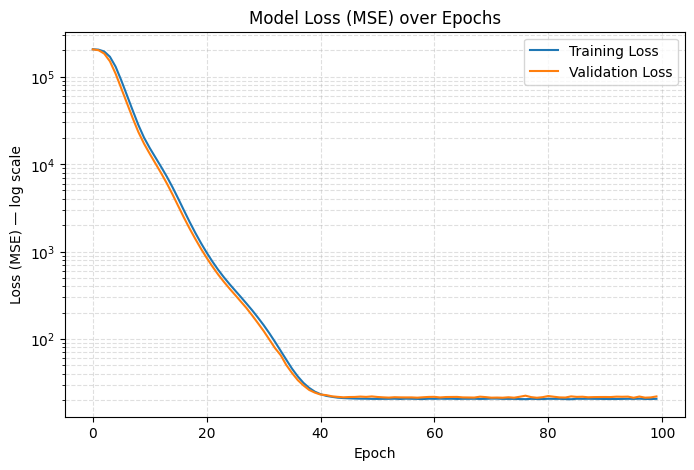

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (MSE) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE) — log scale')
plt.yscale('log')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()

### Actual vs Predicted Scatter Plot

This scatter plot compares the actual power output values against
the values predicted by our model. Each point represents one test
observation.

- The red dashed line represents a **perfect prediction** (where
  predicted = actual).
- The closer the points cluster around this line, the more
  accurate the model's predictions are.

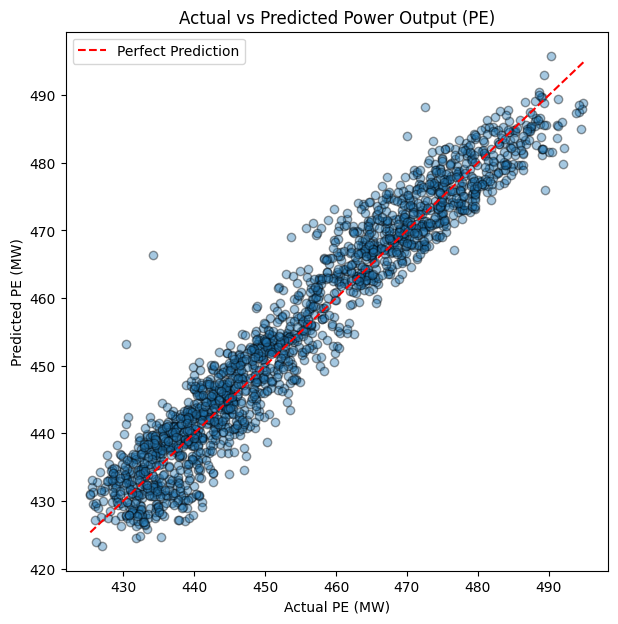

In [41]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted Power Output (PE)')
plt.xlabel('Actual PE (MW)')
plt.ylabel('Predicted PE (MW)')
plt.legend()
plt.show()

### Residual Plot

A residual is the difference between the actual and predicted
value (`Actual - Predicted`) for each observation. Plotting the
residuals helps us check whether the model's errors are random
and evenly distributed around zero, or whether there's a
systematic pattern (which would suggest the model is missing
something in the data).

Ideally, the residuals should be randomly scattered around the
horizontal line at 0, with no clear pattern or trend.

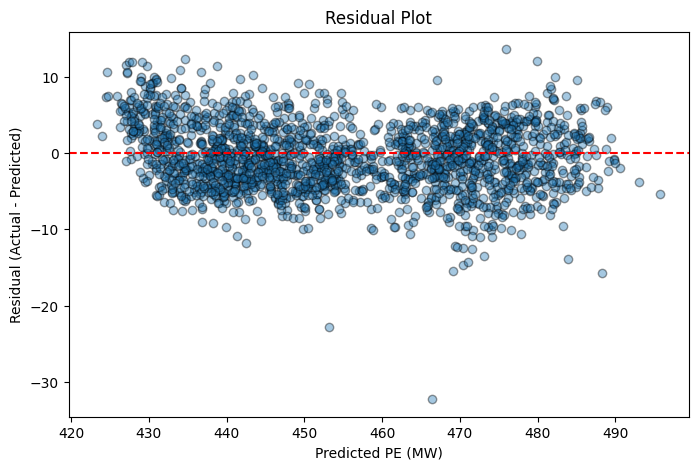

In [42]:
residuals = y_test - y_pred.flatten()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted PE (MW)')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()